C:\Users\gilla\AppData\Local\Temp\ipykernel_12280\1732527397.py:67: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  months = 0 if months.empty else months.dt.to_period("M").nunique()
C:\Users\gilla\AppData\Local\Temp\ipykernel_12280\1732527397.py:108: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  obs1["month"] = obs1["_date"].dt.to_period("M").dt.to_timestamp()


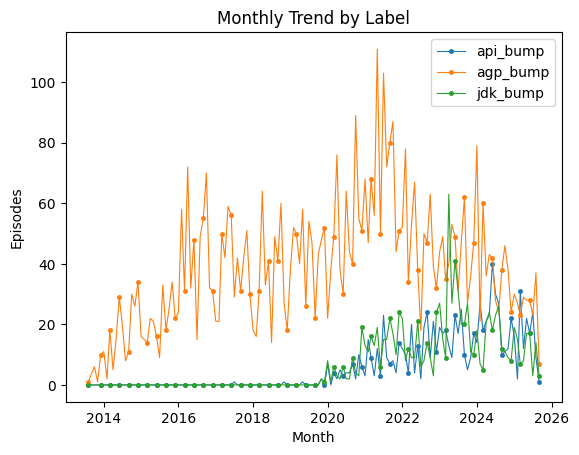

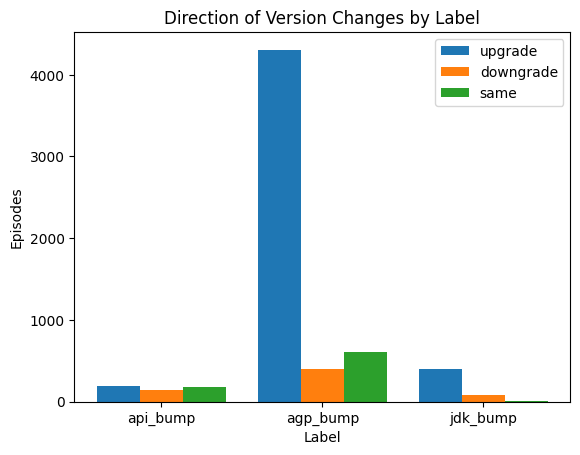

obs_counts: {'Obs 1': 7509, 'Obs 2': 305, 'Obs 3': 1700, 'Obs 4': 9847}


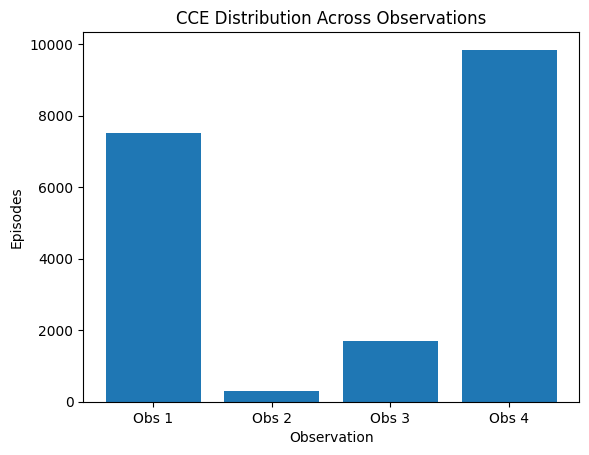

In [15]:
# JUPYTER INLINE RENDERING (safe no-op outside notebooks)
try:
    from IPython import get_ipython
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ Paths (edit for your machine) ------------------
CSV_PATH = r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined\episodes_enriched_combined.csv"
# Optional: where to save PNGs (they’ll also display inline)
OUT_DIR  = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports"
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------ Config ------------------
OBS1_LABELS = ["api_bump", "agp_bump", "jdk_bump"]
OBS_MAP = {
    # Obs 1
    "api_bump": "Obs 1", "agp_bump": "Obs 1", "jdk_bump": "Obs 1",
    # Obs 2
    "timeout_tuning": "Obs 2", "retry_tuning": "Obs 2",
    "orchestrator_toggle": "Obs 2", "wait_strategy_change": "Obs 2",
    # Obs 3
    "matrix_change": "Obs 3", "device_profile_change": "Obs 3",
    "abi_change": "Obs 3", "system_image_change": "Obs 3",
    # Obs 4
    "runner_os_change": "Obs 4", "invocation_change": "Obs 4",
    "external_service_change": "Obs 4",
}

# ------------------ Helpers ------------------
def find_col(df, contains_any, prefer_exact=None):
    if prefer_exact and prefer_exact in df.columns:
        return prefer_exact
    low = {c.lower(): c for c in df.columns}
    for k, v in low.items():
        if any(sub in k for sub in contains_any):
            return v
    return None

def robust_parse_timestamp(val):
    if pd.isna(val): return pd.NaT
    s = str(val).strip()
    if s.isdigit():
        n = int(s)
        unit = "ms" if n > 1e11 else "s"
        return pd.to_datetime(n, unit=unit, utc=True, errors="coerce")
    try:
        f = float(s)
        unit = "ms" if f > 1e11 else "s"
        return pd.to_datetime(f, unit=unit, utc=True, errors="coerce")
    except Exception:
        pass
    return pd.to_datetime(s.replace("UTC", "").strip(), utc=True, errors="coerce")

def best_time_column(df):
    cands = [c for c in df.columns if any(k in c.lower() for k in ["date","time","timestamp"])]
    best, best_months, best_frac = None, 0, 0.0
    for c in cands:
        p = df[c].apply(robust_parse_timestamp)
        frac = p.notna().mean()
        months = p.dropna()
        months = 0 if months.empty else months.dt.to_period("M").nunique()
        if (months > best_months) or (months == best_months and frac > best_frac):
            best, best_months, best_frac = c, months, frac
    return best or ("timestamp" if "timestamp" in df.columns else None)

def parse_version_token(s):
    if pd.isna(s): return None
    m = re.search(r"(\d+(?:\.\d+){0,3})", str(s))
    if not m: return None
    try:
        return tuple(int(x) for x in m.group(1).split("."))
    except Exception:
        return None

def compare_versions(old_tup, new_tup):
    if old_tup is None or new_tup is None: return None
    if new_tup > old_tup: return "upgrade"
    if new_tup < old_tup: return "downgrade"
    return "same"

# ------------------ Load ------------------
df = pd.read_csv(CSV_PATH)

PRIMARY_LABEL = "primary_label" if "primary_label" in df.columns else find_col(df, ["primary_label","label"])
assert PRIMARY_LABEL, "No primary_label column found."

TIME_COL = best_time_column(df)
OLD_COL  = find_col(df, ["old_", "_old", "oldvalue"])
NEW_COL  = find_col(df, ["new_", "_new", "newvalue"])
FIELD_COL = find_col(df, ["field","field_name","changed_field","config_field"])

# Filter to Obs 1 rows once
obs1 = df[df[PRIMARY_LABEL].isin(OBS1_LABELS)].copy()

# =============================================================================
# Claim 1 — “Upgrades are a steady force”  (Monthly trend by label)
# =============================================================================
if TIME_COL:
    obs1["_date"] = obs1[TIME_COL].apply(robust_parse_timestamp)
    obs1 = obs1.dropna(subset=["_date"])
    if not obs1.empty:
        obs1["month"] = obs1["_date"].dt.to_period("M").dt.to_timestamp()
        monthly = (obs1.groupby(["month", PRIMARY_LABEL]).size()
                        .reset_index(name="episodes")
                        .sort_values(["month", PRIMARY_LABEL]))
        wide = monthly.pivot(index="month", columns=PRIMARY_LABEL, values="episodes").fillna(0)
        for lbl in OBS1_LABELS:
            if lbl not in wide.columns: wide[lbl] = 0
        wide = wide[OBS1_LABELS]

        fig, ax = plt.subplots()
        for lbl in OBS1_LABELS:
            ax.plot(wide.index, wide[lbl], marker="o", label=lbl,linewidth=0.8, markersize=3, markeredgewidth=0.5,markevery=3)
        ax.set_title("Monthly Trend by Label")
        ax.set_xlabel("Month"); ax.set_ylabel("Episodes"); ax.legend()
        fig.savefig(os.path.join(OUT_DIR, "OBS1_Detected_FACT1_monthly_trend_by_label.png"), dpi=200, bbox_inches="tight")
        plt.show()
    else:
        # Fallback: counts
        counts = df[PRIMARY_LABEL].value_counts().reindex(OBS1_LABELS, fill_value=0)
        fig, ax = plt.subplots()
        ax.bar(counts.index, counts.values)
        ax.set_title("Counts by Label")
        ax.set_xlabel("Primary label"); ax.set_ylabel("Episodes")
        fig.savefig(os.path.join(OUT_DIR, "OBS1_Detected_FACT1_counts_by_label.png"), dpi=200, bbox_inches="tight")
        plt.show()
else:
    counts = df[PRIMARY_LABEL].value_counts().reindex(OBS1_LABELS, fill_value=0)
    fig, ax = plt.subplots()
    ax.bar(counts.index, counts.values)
    ax.set_title("Observation 1 — Counts by Label (no time column)")
    ax.set_xlabel("Primary label"); ax.set_ylabel("Episodes")
    fig.savefig(os.path.join(OUT_DIR, "OBS1_Detected_FACT1_counts_by_label.png"), dpi=200, bbox_inches="tight")
    plt.show()

# =============================================================================
# Claim 2 — “Net upward movement; projects keep toolchains current”
# =============================================================================
dir_df = obs1.copy()

def classify_kind(row):
    f = str(row.get(FIELD_COL, "")).lower() if FIELD_COL else ""
    lbl = row[PRIMARY_LABEL]
    if "agp" in f or "android_gradle_plugin" in f or lbl == "agp_bump": return "agp_bump"
    if "api" in f or "compilesdk" in f or lbl == "api_bump":           return "api_bump"
    if "jdk" in f or "java" in f or lbl == "jdk_bump":                  return "jdk_bump"
    return None

dir_df["_kind"] = dir_df.apply(classify_kind, axis=1)
if OLD_COL and NEW_COL:
    dir_df["_old_t"] = dir_df[OLD_COL].apply(parse_version_token)
    dir_df["_new_t"] = dir_df[NEW_COL].apply(parse_version_token)
    dir_df["_dir"]   = dir_df.apply(lambda r: compare_versions(r["_old_t"], r["_new_t"]), axis=1)
else:
    dir_df["_dir"] = None  # still chart zeros if versions aren't parseable

direction_counts = (dir_df.groupby(["_kind", "_dir"]).size().unstack(fill_value=0)
                         .reindex(index=OBS1_LABELS, fill_value=0)
                         .reindex(columns=["upgrade","downgrade","same"], fill_value=0))

labels = direction_counts.index.tolist()
cats   = direction_counts.columns.tolist()
x = np.arange(len(labels))
width = 0.8 / max(len(cats), 1)

fig, ax = plt.subplots()
for i, cat in enumerate(cats):
    ax.bar(x + i*width, direction_counts[cat].values, width, label=cat)
ax.set_xticks(x + width*(len(cats)-1)/2, labels)
ax.set_title("Direction of Version Changes by Label")
ax.set_xlabel("Label"); ax.set_ylabel("Episodes"); ax.legend()
fig.savefig(os.path.join(OUT_DIR, "OBS1_Detected_FACT2_direction_grouped.png"), dpi=200, bbox_inches="tight")
plt.show()

# =============================================================================
# Claim 3 — “Version pressure dominates vs structural rewiring”
# =============================================================================
df["_observation"] = df[PRIMARY_LABEL].map(OBS_MAP).fillna("Other/Unmapped")
obs_counts = df["_observation"].value_counts().reindex(
    ["Obs 1","Obs 2","Obs 3","Obs 4"], fill_value=0
)
print("obs_counts:", obs_counts.to_dict())  # sanity check

fig, ax = plt.subplots()
ax.bar(list(obs_counts.index), list(obs_counts.values))
ax.set_title("CCE Distribution Across Observations")
ax.set_xlabel("Observation"); ax.set_ylabel("Episodes")
fig.savefig(os.path.join(OUT_DIR, "OBS1_Detected_FACT3_share_by_observation.png"), dpi=200, bbox_inches="tight")
plt.show()


Reading: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined\episodes_enriched_combined.csv


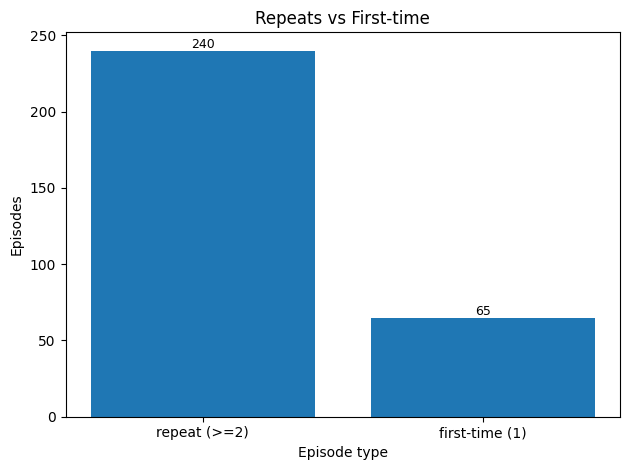

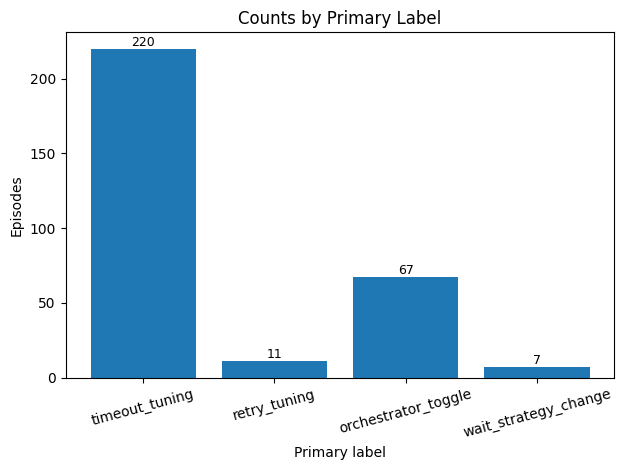

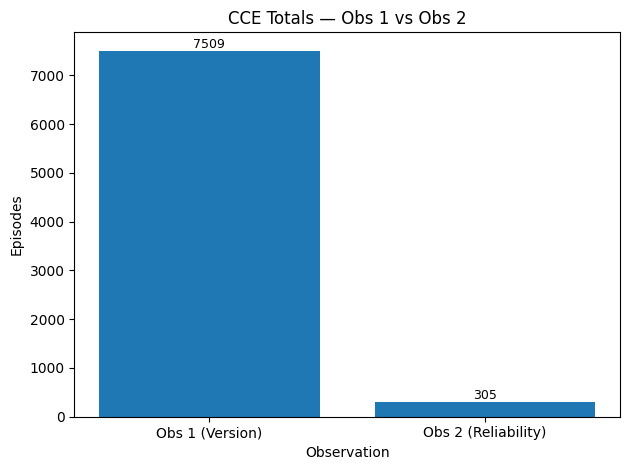

Saved figures:
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs2_fact1_repeat_vs_first.png
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs2_fact2_counts_by_label.png
 - C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs2_fact3_obs1_vs_obs2.png


In [17]:
# Jupyter inline rendering (safe no-op if not in a notebook)
try:
    from IPython import get_ipython
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

import os
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ Paths (edit if needed) ------------------
INPUT_DIR = r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined"
OUT_DIR   = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports"
os.makedirs(OUT_DIR, exist_ok=True)

# Try the expected filename first; otherwise, pick a matching CSV in the folder
INPUT_CSV = os.path.join(INPUT_DIR, "episodes_enriched_combined.csv")
if not os.path.exists(INPUT_CSV):
    candidates = sorted(glob.glob(os.path.join(INPUT_DIR, "*episodes_enriched*.csv"))) \
              or sorted(glob.glob(os.path.join(INPUT_DIR, "*.csv")))
    if not candidates:
        raise FileNotFoundError(f"No CSV found in {INPUT_DIR}")
    INPUT_CSV = candidates[0]
print(f"Reading: {INPUT_CSV}")

# ------------------ Config ------------------
OBS2_LABELS = ["timeout_tuning", "retry_tuning", "orchestrator_toggle", "wait_strategy_change"]
OBS1_LABELS = ["api_bump", "agp_bump", "jdk_bump"]

OBS_MAP = {
    # Obs 1
    "api_bump": "Obs 1", "agp_bump": "Obs 1", "jdk_bump": "Obs 1",
    # Obs 2
    "timeout_tuning": "Obs 2", "retry_tuning": "Obs 2",
    "orchestrator_toggle": "Obs 2", "wait_strategy_change": "Obs 2",
    # Obs 3
    "matrix_change": "Obs 3", "device_profile_change": "Obs 3",
    "abi_change": "Obs 3", "system_image_change": "Obs 3",
    # Obs 4
    "runner_os_change": "Obs 4", "invocation_change": "Obs 4",
    "external_service_change": "Obs 4",
}

# ------------------ Helpers ------------------
def find_col(df, needles):
    """Return first column whose lowercase name contains all needle substrings."""
    for c in df.columns:
        lc = c.lower()
        if all(n in lc for n in needles):
            return c
    return None

# ------------------ Load ------------------
df = pd.read_csv(INPUT_CSV)

PRIMARY = "primary_label" if "primary_label" in df.columns else find_col(df, ["primary","label"])
if not PRIMARY:
    raise RuntimeError("Could not find a 'primary_label' column.")

REPEAT = "repeat_index" if "repeat_index" in df.columns else find_col(df, ["repeat","index"])
if not REPEAT:
    raise RuntimeError("Could not find a 'repeat_index' column.")

# Be robust if repeat_index is not numeric
df[REPEAT] = pd.to_numeric(df[REPEAT], errors="coerce")

# ------------------ Filter for Obs 2 and Obs 1 ------------------
obs2 = df[df[PRIMARY].isin(OBS2_LABELS)].copy()
obs1 = df[df[PRIMARY].isin(OBS1_LABELS)].copy()

# =============================================================================
# Fact 1 — Iterative tuning (repeats vs first-time)
# =============================================================================
obs2["is_repeat"] = (obs2[REPEAT].fillna(1) >= 2)
repeat_counts = obs2["is_repeat"].value_counts().rename(index={True: "repeat (>=2)", False: "first-time (1)"})
repeat_counts = repeat_counts.reindex(["repeat (>=2)", "first-time (1)"], fill_value=0)

plt.figure()
plt.bar(repeat_counts.index, repeat_counts.values)
plt.title("Repeats vs First-time")
plt.xlabel("Episode type")
plt.ylabel("Episodes")
for i, v in enumerate(repeat_counts.values):
    plt.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
out1 = os.path.join(OUT_DIR, "obs2_fact1_repeat_vs_first.png")
plt.tight_layout()
plt.savefig(out1, dpi=200, bbox_inches="tight")
plt.show()

# =============================================================================
# Fact 2 — Focus on time budgets and orchestration (counts by label)
# =============================================================================
counts_by_label = obs2[PRIMARY].value_counts().reindex(OBS2_LABELS, fill_value=0)

plt.figure()
plt.bar(counts_by_label.index, counts_by_label.values)
plt.title("Counts by Primary Label")
plt.xlabel("Primary label")
plt.ylabel("Episodes")
plt.xticks(rotation=15)
for i, v in enumerate(counts_by_label.values):
    plt.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
out2 = os.path.join(OUT_DIR, "obs2_fact2_counts_by_label.png")
plt.tight_layout()
plt.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()

# =============================================================================
# Fact 3 — Lower volume than version pressure (Obs 1 vs Obs 2 totals)
# =============================================================================
df["_observation"] = df[PRIMARY].map(OBS_MAP).fillna("Other")
totals = df["_observation"].value_counts()

vals = pd.Series({
    "Obs 1 (Version)": int(totals.get("Obs 1", 0)),
    "Obs 2 (Reliability)": int(totals.get("Obs 2", 0)),
})

plt.figure()
plt.bar(vals.index, vals.values)
plt.title("CCE Totals — Obs 1 vs Obs 2")
plt.xlabel("Observation")
plt.ylabel("Episodes")
for i, v in enumerate(vals.values):
    plt.text(i, v, str(int(v)), ha="center", va="bottom", fontsize=9)
out3 = os.path.join(OUT_DIR, "obs2_fact3_obs1_vs_obs2.png")
plt.tight_layout()
plt.savefig(out3, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" -", out1)
print(" -", out2)
print(" -", out3)


Loading: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined\episodes_enriched_combined.csv
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact1_matrix_change_expansion_contraction_reshuffle.png


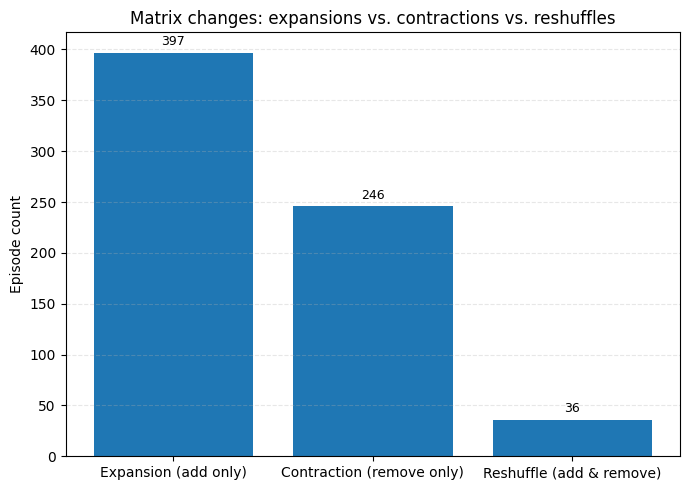

Per-repo intensity • median=4.0 • p75=10.0
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact2_first_vs_repeat.png


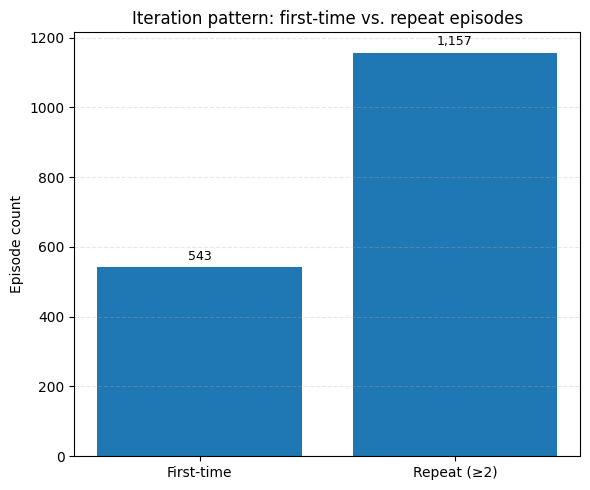

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact3_abi_trends.png


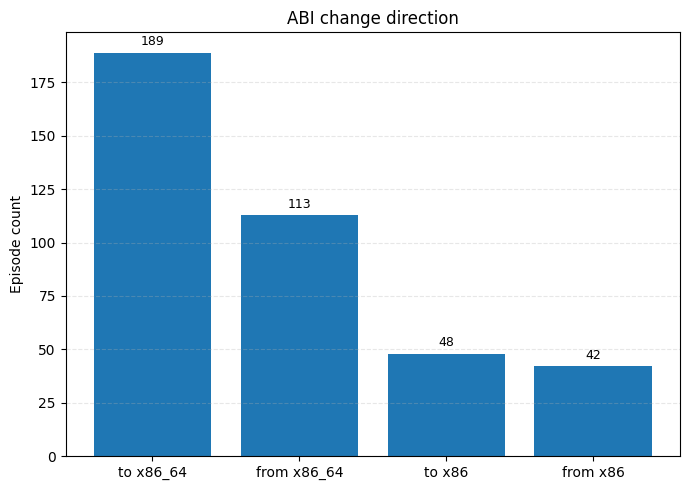

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact4_system_image_toggles.png


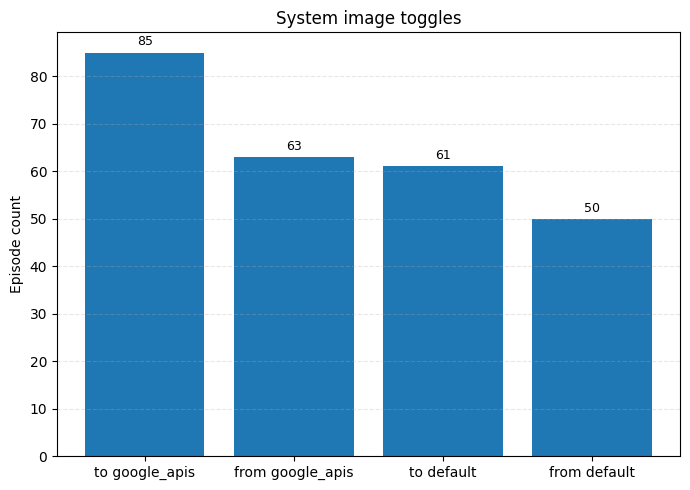

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact5_device_profile_edits.png


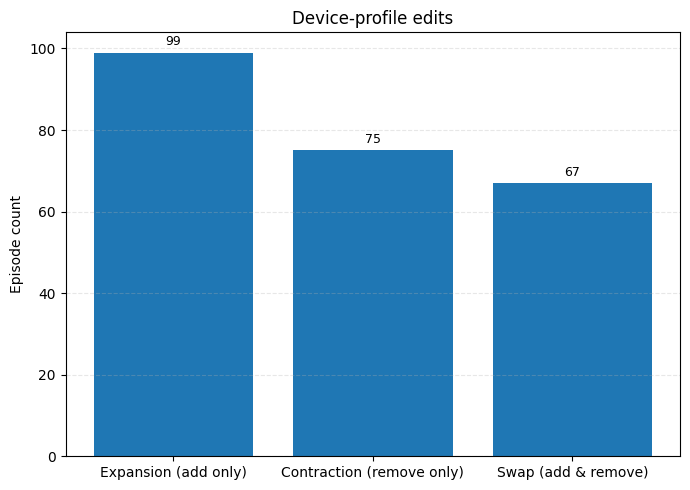

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact6_speed_up_label_share.png


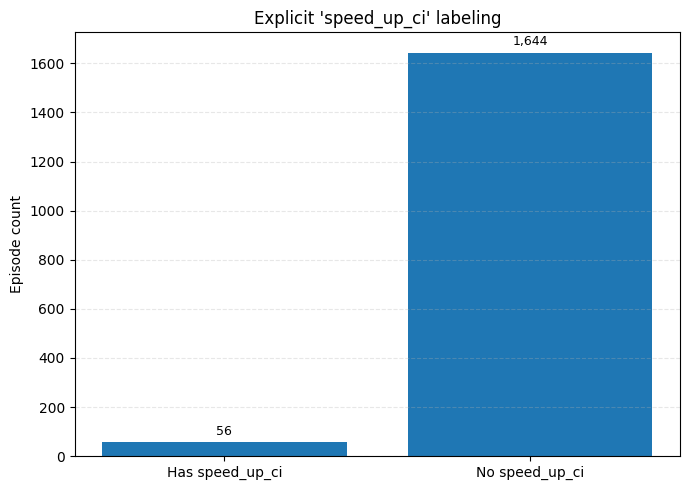

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs3_fact7_relative_weight_vs_version_pressure.png


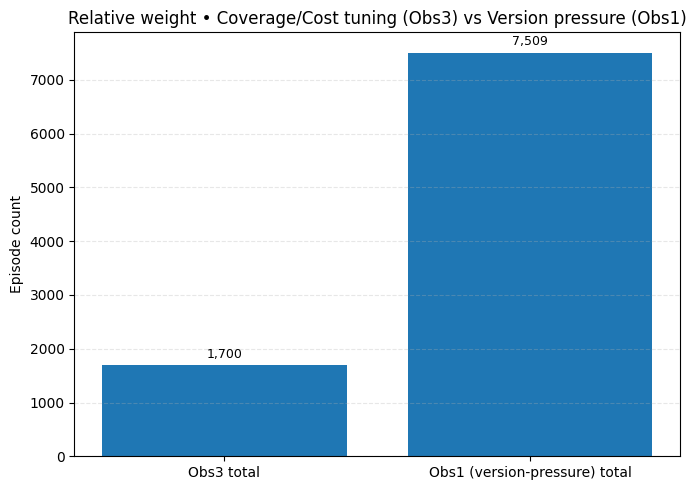

Done.


In [20]:
# -*- coding: utf-8 -*-
"""
Observation 3 – Supporting Plots
Reads the combined RQ2 dataset and produces one supporting plot per detected fact.
Saves plots to: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports
"""

import os
import glob
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# CONFIGURE YOUR PATHS HERE
# ----------------------------
INPUT_DIR = r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined"
OUTPUT_DIR = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports"

# ----------------------------
# HELPERS
# ----------------------------
def ensure_outdir(path: str):
    os.makedirs(path, exist_ok=True)

def find_input_file(input_dir: str) -> str:
    """
    Prefer 'episodes_enriched_combined.csv' if present,
    otherwise pick the first *.csv in the folder.
    As a fallback, try a *.jsonl (line-delimited JSON).
    """
    preferred = os.path.join(input_dir, "episodes_enriched_combined.csv")
    if os.path.isfile(preferred):
        return preferred

    csvs = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
    if csvs:
        return csvs[0]

    jsonls = sorted(glob.glob(os.path.join(input_dir, "*.jsonl")))
    if jsonls:
        return jsonls[0]

    raise FileNotFoundError(f"No CSV or JSONL files found in: {input_dir}")

def load_dataset(path: str) -> pd.DataFrame:
    if path.lower().endswith(".csv"):
        # robust CSV loading
        try:
            return pd.read_csv(path)
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="utf-8", errors="replace")
    elif path.lower().endswith(".jsonl"):
        return pd.read_json(path, lines=True)
    else:
        raise ValueError(f"Unsupported file type: {path}")

def parse_list_field(x):
    """Safely parse JSON-like lists stored as strings; return [] on error/NaN."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

def annotate_bars(ax):
    """Write integer labels above bars."""
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f"{int(height):,}", (p.get_x() + p.get_width()/2.0, height),
                    ha='center', va='bottom', fontsize=9, rotation=0, xytext=(0, 3), textcoords='offset points')

def save_and_show(fig, filename):
    out_path = os.path.join(OUTPUT_DIR, filename)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

# ----------------------------
# LOAD DATA
# ----------------------------
ensure_outdir(OUTPUT_DIR)
infile = find_input_file(INPUT_DIR)
print(f"Loading: {infile}")
df = load_dataset(infile)

# Basic, defensive column checks (rename analogs if needed)
colmap = {c.lower(): c for c in df.columns}
def need(col):
    if col in df.columns:
        return col
    # try case-insensitive match
    if col in colmap:
        return colmap[col]
    raise KeyError(f"Required column '{col}' not found in dataset. Available: {list(df.columns)}")

PRIMARY = need("primary_label")
ADDED = need("added_items")
REMOVED = need("removed_items")
NEW = need("new_value")
OLD = need("old_value")
REPEAT_IDX = need("repeat_index")
REPO = need("repo")
SEC_JSON = need("secondary_labels_json") if "secondary_labels_json" in df.columns else None

# Subset: Observation 3 labels
obs3_labels = ["matrix_change", "device_profile_change", "abi_change", "system_image_change"]
obs3 = df[df[PRIMARY].isin(obs3_labels)].copy()

# Coerce repeat_index to numeric
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    obs3["repeat_index_num"] = pd.to_numeric(obs3[REPEAT_IDX], errors="coerce")

# ---------------------------------------------------------
# FACT 1: Matrix changes – expansions vs contractions vs reshuffles
# ---------------------------------------------------------
m = obs3[obs3[PRIMARY] == "matrix_change"][[ADDED, REMOVED]].copy()
m["added"] = m[ADDED].notna()
m["removed"] = m[REMOVED].notna()

counts_fact1 = {
    "Expansion (add only)": int(((m["added"]) & (~m["removed"])).sum()),
    "Contraction (remove only)": int(((~m["added"]) & (m["removed"])).sum()),
    "Reshuffle (add & remove)": int(((m["added"]) & (m["removed"])).sum()),
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact1.keys()), list(counts_fact1.values()))
ax.set_title("Matrix changes: expansions vs. contractions vs. reshuffles")
ax.set_ylabel("Episode count")
ax.set_xlabel("")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact1_matrix_change_expansion_contraction_reshuffle.png")

# ---------------------------------------------------------
# FACT 2: Iterative changes – repeat vs first-time
# ---------------------------------------------------------
first_time = int((obs3["repeat_index_num"] == 1).sum())
repeat = int((obs3["repeat_index_num"] >= 2).sum())
counts_fact2 = {"First-time": first_time, "Repeat (≥2)": repeat}
# Print supporting per-repo intensity (no extra plot required)
repo_counts = obs3.groupby(REPO).size()
print(f"Per-repo intensity • median={repo_counts.median()} • p75={repo_counts.quantile(0.75)}")

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact2.keys()), list(counts_fact2.values()))
ax.set_title("Iteration pattern: first-time vs. repeat episodes")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact2_first_vs_repeat.png")

# ---------------------------------------------------------
# FACT 3: ABI trends – movements to/from x86_64 (and x86)
# ---------------------------------------------------------
abi = obs3[obs3[PRIMARY] == "abi_change"][[NEW, OLD]].copy()
abi["new_list"] = abi[NEW].apply(parse_list_field)
abi["old_list"] = abi[OLD].apply(parse_list_field)

to_x86_64 = int(((abi["new_list"].apply(lambda L: "x86_64" in L)) & (~abi["old_list"].apply(lambda L: "x86_64" in L))).sum())
from_x86_64 = int(((abi["old_list"].apply(lambda L: "x86_64" in L)) & (~abi["new_list"].apply(lambda L: "x86_64" in L))).sum())
to_x86 = int(((abi["new_list"].apply(lambda L: "x86" in L)) & (~abi["old_list"].apply(lambda L: "x86" in L))).sum())
from_x86 = int(((abi["old_list"].apply(lambda L: "x86" in L)) & (~abi["new_list"].apply(lambda L: "x86" in L))).sum())

counts_fact3 = {
    "to x86_64": to_x86_64,
    "from x86_64": from_x86_64,
    "to x86": to_x86,
    "from x86": from_x86,
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact3.keys()), list(counts_fact3.values()))
ax.set_title("ABI change direction")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact3_abi_trends.png")

# ---------------------------------------------------------
# FACT 4: System image toggles – google_apis vs default
# ---------------------------------------------------------
si = obs3[obs3[PRIMARY] == "system_image_change"][[NEW, OLD]].copy()
si["new_list"] = si[NEW].apply(parse_list_field)
si["old_list"] = si[OLD].apply(parse_list_field)

to_google_apis = int(((si["new_list"].apply(lambda L: "google_apis" in L)) & (~si["old_list"].apply(lambda L: "google_apis" in L))).sum())
from_google_apis = int(((si["old_list"].apply(lambda L: "google_apis" in L)) & (~si["new_list"].apply(lambda L: "google_apis" in L))).sum())
to_default = int(((si["new_list"].apply(lambda L: "default" in L)) & (~si["old_list"].apply(lambda L: "default" in L))).sum())
from_default = int(((si["old_list"].apply(lambda L: "default" in L)) & (~si["new_list"].apply(lambda L: "default" in L))).sum())

counts_fact4 = {
    "to google_apis": to_google_apis,
    "from google_apis": from_google_apis,
    "to default": to_default,
    "from default": from_default,
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact4.keys()), list(counts_fact4.values()))
ax.set_title("System image toggles")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact4_system_image_toggles.png")

# ---------------------------------------------------------
# FACT 5: Device-profile edits – expand vs contract vs swap
# ---------------------------------------------------------
dp = obs3[obs3[PRIMARY] == "device_profile_change"][[ADDED, REMOVED]].copy()
dp["added"] = dp[ADDED].notna()
dp["removed"] = dp[REMOVED].notna()

counts_fact5 = {
    "Expansion (add only)": int(((dp["added"]) & (~dp["removed"])).sum()),
    "Contraction (remove only)": int(((~dp["added"]) & (dp["removed"])).sum()),
    "Swap (add & remove)": int(((dp["added"]) & (dp["removed"])).sum()),
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact5.keys()), list(counts_fact5.values()))
ax.set_title("Device-profile edits")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact5_device_profile_edits.png")

# ---------------------------------------------------------
# FACT 6: Explicit “speed_up_ci” label presence within Obs3
# ---------------------------------------------------------
def has_speed(label_json):
    try:
        L = parse_list_field(label_json)
        return "speed_up_ci" in L
    except Exception:
        return False

if SEC_JSON is not None:
    obs3["speed_up_ci"] = obs3[SEC_JSON].apply(has_speed)
else:
    obs3["speed_up_ci"] = False  # if column missing, treat as none present

counts_fact6 = {
    "Has speed_up_ci": int(obs3["speed_up_ci"].sum()),
    "No speed_up_ci": int((~obs3["speed_up_ci"]).sum()),
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact6.keys()), list(counts_fact6.values()))
ax.set_title("Explicit 'speed_up_ci' labeling")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact6_speed_up_label_share.png")

# ---------------------------------------------------------
# FACT 7: Relative weight – Obs3 vs Version-pressure categories (Obs1-ish)
# ---------------------------------------------------------
# Approximate Obs1 categories commonly seen in this dataset:
obs1_like = ["agp_bump", "jdk_bump", "api_bump"]
obs1_total = int(df[df[PRIMARY].isin(obs1_like)].shape[0])
obs3_total = int(obs3.shape[0])

counts_fact7 = {"Obs3 total": obs3_total, "Obs1 (version-pressure) total": obs1_total}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact7.keys()), list(counts_fact7.values()))
ax.set_title("Relative weight • Coverage/Cost tuning (Obs3) vs Version pressure (Obs1)")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs3_fact7_relative_weight_vs_version_pressure.png")

print("Done.")


Loading: C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined\episodes_enriched_combined.csv
Obs4 total = 9,847 / All total = 19,361
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact1_share_vs_all.png


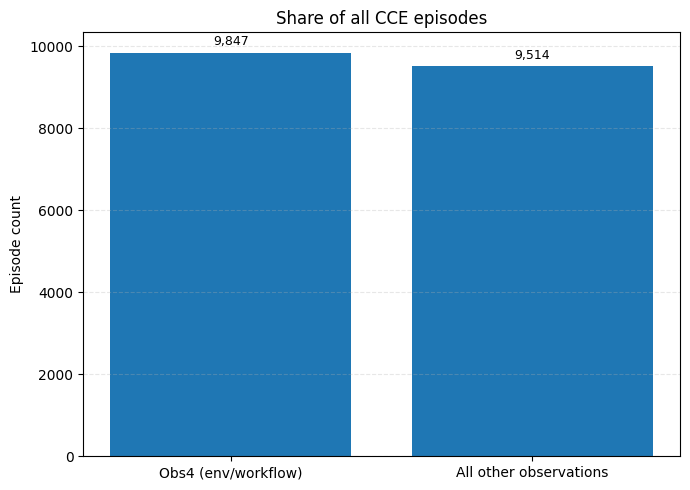

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact2_label_mix.png


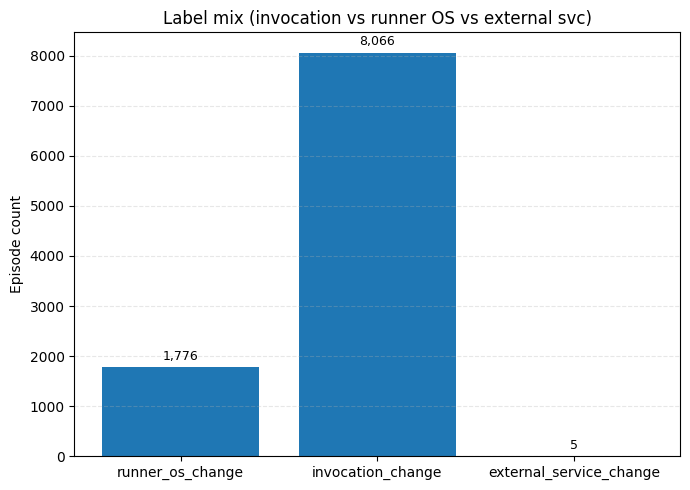

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact3_first_vs_repeat.png


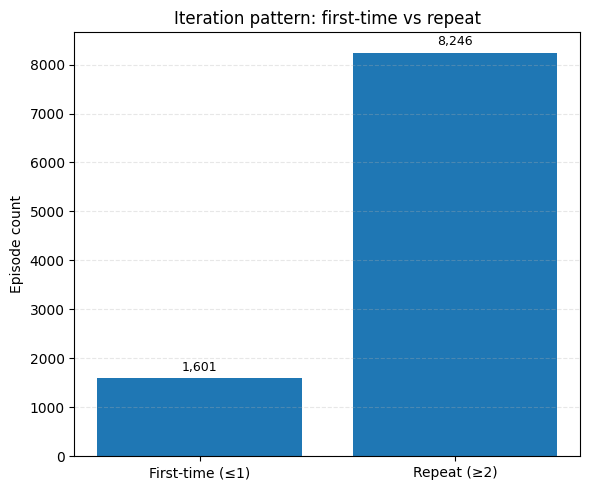

Per-repo intensity • median=17.0 • p75=41.0
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact4_per_repo_intensity_hist.png


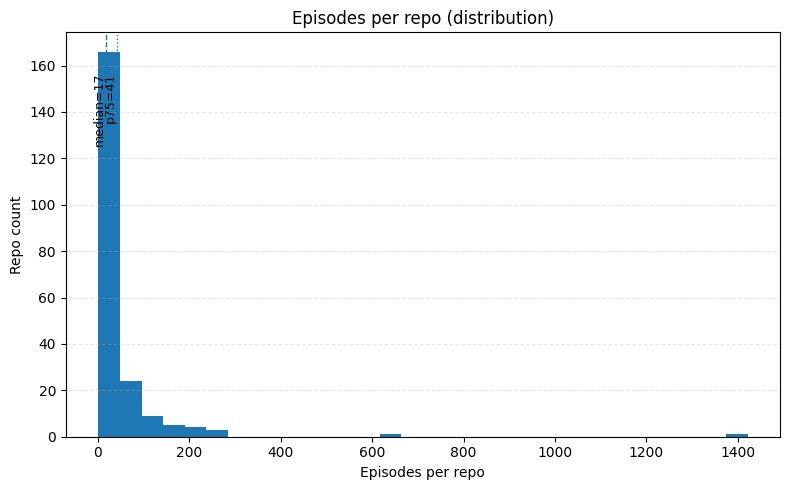

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact5_external_service_rarity.png


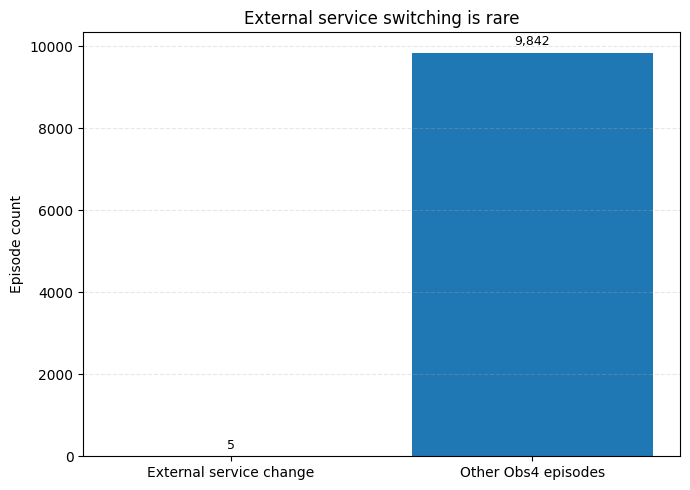

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact6_repeat_rate_comparison.png


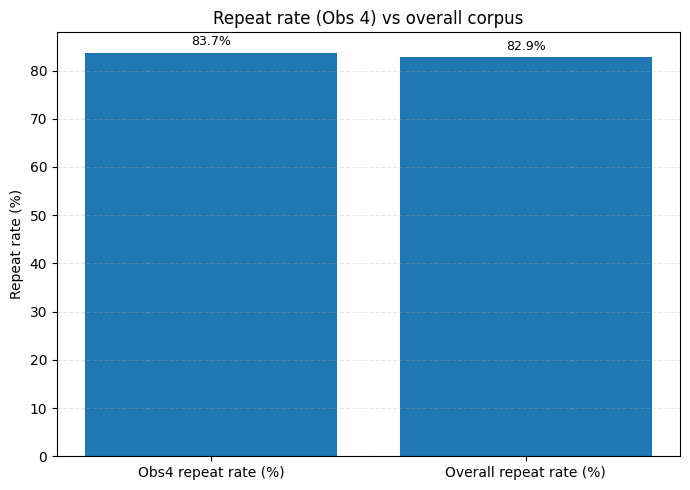

Top secondary cues in Obs4: [('migrate_ci', 9847), ('upgrade', 2140), ('fix_build', 1463), ('cleanup', 275), ('speed_up_ci', 271), ('revert', 172), ('adopt_diy', 84), ('adopt_gmd', 27), ('flake_mitigation', 19), ('drop_gmd', 16)]
Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports\obs4_fact7_secondary_cues.png


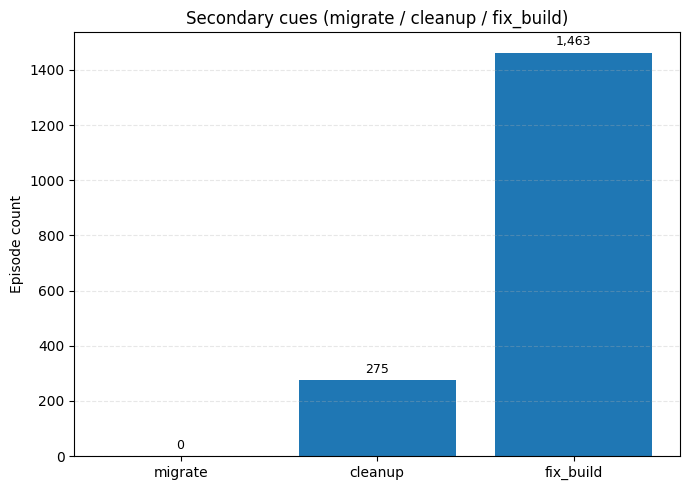

Done.


In [21]:
# -*- coding: utf-8 -*-
"""
Observation 4 – Supporting Plots (CI Runtime & Workflow Environment Changes)
- Loads the RQ2 combined dataset from your Windows path
- Computes metrics for Obs 4 (runner_os_change, invocation_change, external_service_change)
- Creates one plot per detected fact and saves PNGs to the requested output folder
"""

import os
import glob
import ast
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================
# CONFIGURE YOUR PATHS HERE
# ===========================
INPUT_DIR = r"C:\Android Mobile App\Step2_Clone_Repo\Type_1\Aug_10\RQ2\combined"
OUTPUT_DIR = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\RQ2\Plots and Supports"

# ===========================
# HELPERS
# ===========================
def ensure_outdir(path: str):
    os.makedirs(path, exist_ok=True)

def find_input_file(input_dir: str) -> str:
    """
    Prefer 'episodes_enriched_combined.csv' if present,
    otherwise pick the first *.csv in the folder.
    As a fallback, try a *.jsonl (line-delimited JSON).
    """
    preferred = os.path.join(input_dir, "episodes_enriched_combined.csv")
    if os.path.isfile(preferred):
        return preferred

    csvs = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
    if csvs:
        return csvs[0]

    jsonls = sorted(glob.glob(os.path.join(input_dir, "*.jsonl")))
    if jsonls:
        return jsonls[0]

    raise FileNotFoundError(f"No CSV or JSONL files found in: {input_dir}")

def load_dataset(path: str) -> pd.DataFrame:
    if path.lower().endswith(".csv"):
        try:
            return pd.read_csv(path)
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding="utf-8", errors="replace")
    elif path.lower().endswith(".jsonl"):
        return pd.read_json(path, lines=True)
    else:
        raise ValueError(f"Unsupported file type: {path}")

def parse_list_field(x):
    """Safely parse JSON-like lists stored as strings; return [] on error/NaN."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(str(x))
    except Exception:
        return []

def need(df: pd.DataFrame, col: str, *aliases):
    """
    Return a present column name (case-insensitive), trying aliases too.
    Raise if none found.
    """
    cols = {c.lower(): c for c in df.columns}
    cand = [col, *(aliases or ())]
    for c in cand:
        got = cols.get(c.lower())
        if got:
            return got
    raise KeyError(f"Required column '{col}' not found. Available: {list(df.columns)}")

def annotate_bars(ax, fmt="{:,.0f}"):
    """Write labels above bars."""
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width()/2.0, height),
                    ha='center', va='bottom', fontsize=9,
                    xytext=(0, 3), textcoords='offset points')

def save_and_show(fig, filename):
    out_path = os.path.join(OUTPUT_DIR, filename)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

# ===========================
# LOAD DATA
# ===========================
ensure_outdir(OUTPUT_DIR)
infile = find_input_file(INPUT_DIR)
print(f"Loading: {infile}")
df = load_dataset(infile)

# Identify required columns (robust to naming)
PRIMARY = need(df, "primary_label")
REPEAT_IDX = need(df, "repeat_index")
REPO = need(df, "repo")

# Secondary labels column (robust detection)
SEC_COL = None
for cand in ["secondary_labels_json", "secondary_labels", "secondary_label_list"]:
    try:
        SEC_COL = need(df, cand)
        break
    except KeyError:
        continue

# Coerce repeat index
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df["repeat_index_num"] = pd.to_numeric(df[REPEAT_IDX], errors="coerce")

# ===========================
# SUBSET: OBSERVATION 4
# ===========================
obs4_labels = ["runner_os_change", "invocation_change", "external_service_change"]
obs4 = df[df[PRIMARY].isin(obs4_labels)].copy()
obs4_total = obs4.shape[0]
all_total = df.shape[0]
print(f"Obs4 total = {obs4_total:,} / All total = {all_total:,}")

# ===========================
# FACT 1: Largest share of all CCEs (scale)
# Plot: Obs4 vs All Others
# ===========================
counts_fact1 = {
    "Obs4 (env/workflow)": obs4_total,
    "All other observations": all_total - obs4_total
}
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact1.keys()), list(counts_fact1.values()))
ax.set_title("Share of all CCE episodes")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs4_fact1_share_vs_all.png")

# ===========================
# FACT 2: Invocation changes dominate the label mix
# Plot: counts by primary_label within Obs4
# ===========================
by_label = obs4[PRIMARY].value_counts().reindex(obs4_labels, fill_value=0)
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(by_label.index.tolist(), by_label.values.tolist())
ax.set_title("Label mix (invocation vs runner OS vs external svc)")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs4_fact2_label_mix.png")

# ===========================
# FACT 3: Highly iterative (repeat-heavy)
# Plot: First-time vs Repeat within Obs4
# ===========================
obs4["is_repeat"] = (obs4["repeat_index_num"] >= 2)
repeat = int(obs4["is_repeat"].sum())
first_time = int((~obs4["is_repeat"]).sum())
counts_fact3 = {"First-time (≤1)": first_time, "Repeat (≥2)": repeat}

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact3.keys()), list(counts_fact3.values()))
ax.set_title("Iteration pattern: first-time vs repeat")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs4_fact3_first_vs_repeat.png")

# ===========================
# FACT 4: Concentrated per repo (sustained activity)
# Plot: Histogram of Obs4 episodes per repo with median/p75 markers
# ===========================
per_repo = obs4.groupby(REPO).size().sort_values(ascending=False)
median_val = float(per_repo.median()) if len(per_repo) else 0.0
p75_val = float(per_repo.quantile(0.75)) if len(per_repo) else 0.0
print(f"Per-repo intensity • median={median_val} • p75={p75_val}")

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)
ax.hist(per_repo.values, bins=30)
ax.set_title("Episodes per repo (distribution)")
ax.set_xlabel("Episodes per repo")
ax.set_ylabel("Repo count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
# Markers for median and p75
ax.axvline(median_val, linestyle='--', linewidth=1)
ax.axvline(p75_val, linestyle=':', linewidth=1)
ax.text(median_val, ax.get_ylim()[1]*0.9, f"median={median_val:.0f}", rotation=90, va='top', ha='right', fontsize=9)
ax.text(p75_val, ax.get_ylim()[1]*0.9, f"p75={p75_val:.0f}", rotation=90, va='top', ha='right', fontsize=9)
save_and_show(fig, "obs4_fact4_per_repo_intensity_hist.png")

# ===========================
# FACT 5: External service switching is rare
# Plot: External-service changes vs Other Obs4
# ===========================
ext_ct = int((obs4[PRIMARY] == "external_service_change").sum())
other_ct = int(obs4_total - ext_ct)
counts_fact5 = {"External service change": ext_ct, "Other Obs4 episodes": other_ct}

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(counts_fact5.keys()), list(counts_fact5.values()))
ax.set_title("External service switching is rare")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs4_fact5_external_service_rarity.png")

# ===========================
# FACT 6: Repeat-heavy vs whole corpus
# Plot: Repeat rate (Obs4) vs Repeat rate (Overall)
# ===========================
overall = df.copy()
overall["is_repeat"] = (overall["repeat_index_num"] >= 2)
obs4_repeat_rate = (repeat / obs4_total * 100.0) if obs4_total else 0.0
overall_repeat_rate = (overall["is_repeat"].sum() / len(overall) * 100.0) if len(overall) else 0.0

rates = {"Obs4 repeat rate (%)": obs4_repeat_rate, "Overall repeat rate (%)": overall_repeat_rate}

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(rates.keys()), list(rates.values()))
ax.set_title("Repeat rate (Obs 4) vs overall corpus")
ax.set_ylabel("Repeat rate (%)")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax, fmt="{:,.1f}%")
save_and_show(fig, "obs4_fact6_repeat_rate_comparison.png")

# ===========================
# FACT 7: Secondary cues emphasize migrations/maintenance
# Plot: Counts for selected cues: migrate, cleanup, fix_build
# ===========================
cues = ["migrate", "cleanup", "fix_build"]
cue_counts = {k: 0 for k in cues}

if SEC_COL is not None:
    sec_lists = obs4[SEC_COL].apply(parse_list_field)
    flat = [str(item) for sub in sec_lists for item in (sub if isinstance(sub, list) else [])]
    ctr = Counter(flat)
    for k in cues:
        cue_counts[k] = int(ctr.get(k, 0))
    # optional: print top 10 for debugging/context
    print("Top secondary cues in Obs4:", ctr.most_common(10))
else:
    print("No secondary labels column found; cue counts set to zero.")

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.bar(list(cue_counts.keys()), list(cue_counts.values()))
ax.set_title("Secondary cues (migrate / cleanup / fix_build)")
ax.set_ylabel("Episode count")
ax.grid(axis='y', linestyle='--', alpha=0.3)
annotate_bars(ax)
save_and_show(fig, "obs4_fact7_secondary_cues.png")

print("Done.")
